# **Brain Tumor**
###Julieta Madrigal Flores
###Lunes 6 de abril 2026

In [71]:
import pandas as pd
import numpy as np

In [72]:
# CARGAR DATASET
data = pd.read_csv('brain_tumor_dataset.csv')

In [73]:
data.shape
# filas, columnas

(20000, 19)

In [74]:
data.describe()

,Patient_ID,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,49.433700,5.236552,70.131699,1.547701
std,5773.647028,17.389296,2.754359,17.270834,0.835995
min,1.000000,20.000000,0.500410,40.002386,0.100017
25%,5000.750000,34.000000,2.836686,55.224439,0.830433
50%,10000.500000,49.000000,5.200675,70.305066,1.541821
75%,15000.250000,65.000000,7.624299,85.043395,2.262484
max,20000.000000,79.000000,9.999420,99.998125,2.999835


In [75]:
data.head()
# categoricas  = location, histology, symptom_x
# categoricas ordinarias = stage (sigue un orden)
# bools = gender, tumor_type, radiation_treatment, surgey_performed, family_history, MRI_Result, Follow_Up_required, chemotherapy
# numericas int = age
# numericas float = tumor_size en cm, tumor_growth_rate en cm al mes

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes


In [76]:
data['Gender'].unique() # categorico no ordinal = no tiene orden

array(['Male', 'Female'], dtype=object)

In [77]:
data['Gender'].value_counts()

,count
Gender,
Female,10016
Male,9984


In [78]:
data.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Tumor_Type,0
Tumor_Size,0
Location,0
Histology,0
Stage,0
Symptom_1,0
Symptom_2,0


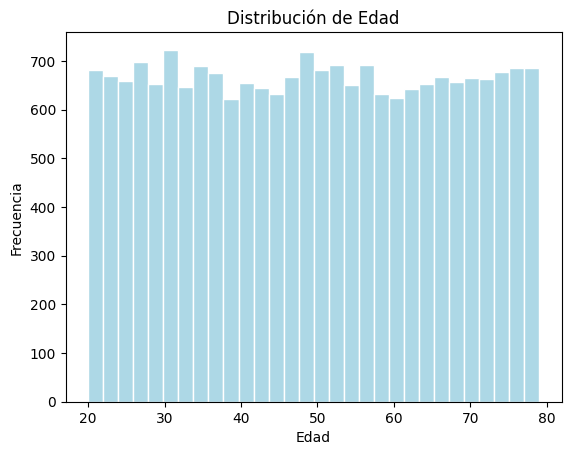

In [79]:
# edad
import matplotlib.pyplot as plt
data['Age'].plot.hist(bins=30, color='lightblue', edgecolor='white')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


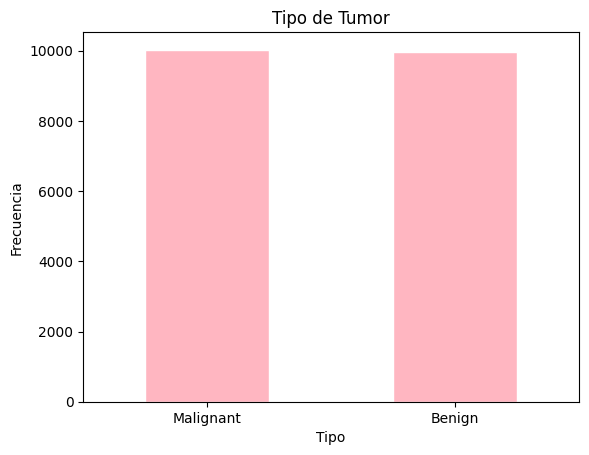

In [80]:
# tipo de tumor

data['Tumor_Type'].value_counts().plot.bar(color='lightpink', edgecolor='white')
plt.title('Tipo de Tumor')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()



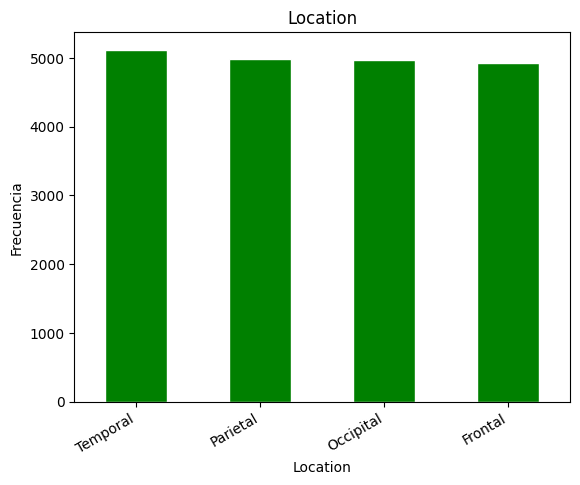

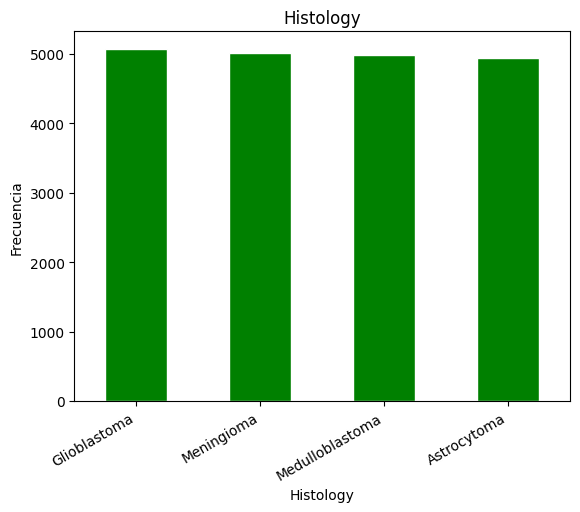

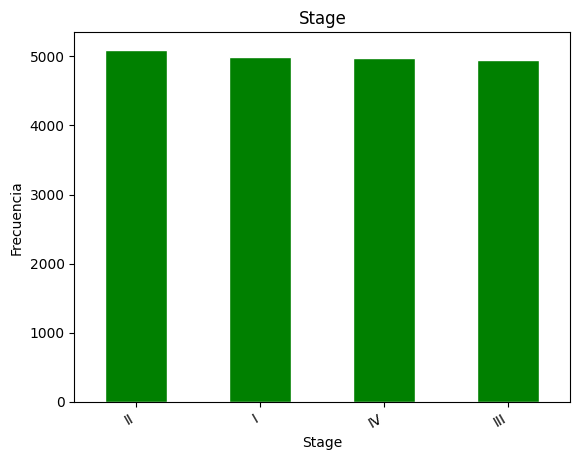

In [81]:
cat_cols = ['Location', 'Histology', 'Stage']

for col in cat_cols:
    data[col].value_counts().plot.bar(color='green', edgecolor='white')
    plt.title(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=30, ha='right')
    plt.show()

array([[<Axes: title={'center': 'Patient_ID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Tumor_Size'}>,
        <Axes: title={'center': 'Survival_Rate'}>],
       [<Axes: title={'center': 'Tumor_Growth_Rate'}>, <Axes: >]],
      dtype=object)

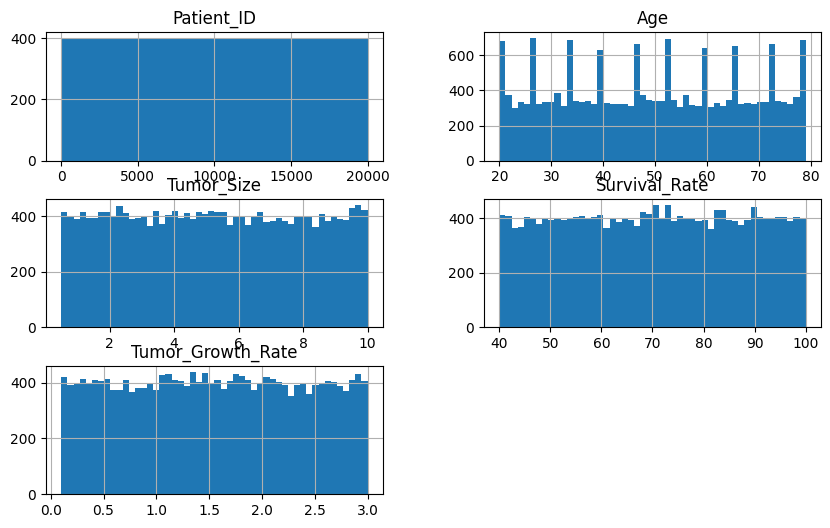

In [82]:
# obtener los histogramas de la distribucion
data.hist(bins=50, figsize=(10,6))

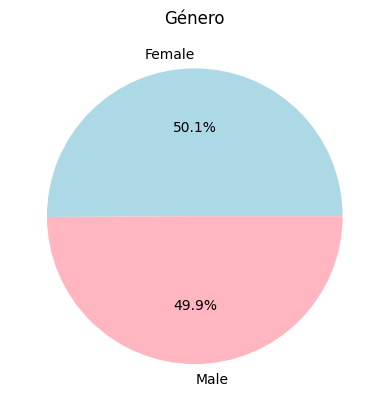

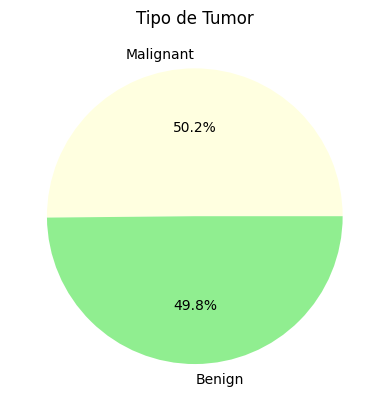

Radiación:
Radiation_Treatment
Yes    10021
No      9979
Name: count, dtype: int64

Quimioterapia:
Chemotherapy
Yes    10097
No      9903
Name: count, dtype: int64


In [83]:
# Género
data['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightpink'])
plt.title('Género')
plt.ylabel('')
plt.show()

# Tipo de Tumor
data['Tumor_Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightyellow', 'lightgreen'])
plt.title('Tipo de Tumor')
plt.ylabel('')
plt.show()

# Conteo de Radiación y Quimioterapia
print("Radiación:")
print(data['Radiation_Treatment'].value_counts())

print("\nQuimioterapia:")
print(data['Chemotherapy'].value_counts())

In [84]:
ambos = ((data['Radiation_Treatment'] == 'Yes') & (data['Chemotherapy'] == 'Yes')).sum()
print(f"Pacientes que recibieron radiación Y quimioterapia: {ambos}")

Pacientes que recibieron radiación Y quimioterapia: 5111


In [85]:
pacientes_filtrados = data[(data['Radiation_Treatment'] == 'Yes') & (data['Chemotherapy'] == 'Yes') & (data['Surgery_Performed'] == 'Yes')]
pacientes_filtrados.head()

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
12,13,71,Female,Benign,5.476302,Temporal,Glioblastoma,IV,Vision Issues,Vision Issues,Headache,Yes,Yes,Yes,69.798219,0.262610,No,Negative,No
17,18,67,Male,Malignant,2.154555,Temporal,Meningioma,I,Headache,Nausea,Vision Issues,Yes,Yes,Yes,55.610579,2.610649,No,Positive,No
25,26,49,Female,Benign,0.989937,Temporal,Meningioma,IV,Seizures,Headache,Nausea,Yes,Yes,Yes,68.384921,0.462728,No,Positive,No
28,29,67,Male,Malignant,9.269300,Temporal,Astrocytoma,III,Vision Issues,Seizures,Vision Issues,Yes,Yes,Yes,94.069342,2.408051,Yes,Positive,No


In [86]:
len(pacientes_filtrados)

2590

## Definimos X y Y

In [87]:
X = data.drop(columns=['Patient_ID', 'Tumor_Type'])
y = data['Tumor_Type']

# P(y=1 | x=1) donde y=1 significa que es un tumor malingo

In [88]:
y = (data['Tumor_Type'] == 'Malignant').astype(int)
print(y.value_counts())

Tumor_Type
1    10030
0     9970
Name: count, dtype: int64


## Feature engineering

In [89]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [90]:
X[['Stage']]

,Stage
0,III
1,II
2,I
3,IV
4,I
...,...
19995,III
19996,III
19997,I
19998,III


In [91]:
# para Stage, lo transformamos a num
categories=['I','II','III','IV']
num_var= OrdinalEncoder(categories=[categories])

# Columnas
bool_cols    = ['Radiation_Treatment', 'Surgery_Performed', 'Chemotherapy','Family_History', 'MRI_Result', 'Follow_Up_Required', 'Gender']
num_cols     = ['Age', 'Tumor_Size', 'Tumor_Growth_Rate']
cat_cols = ['Location', 'Histology']

In [92]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('bool',OneHotEncoder(),  bool_cols),
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(), cat_cols),
    ('catord', num_var, ["Stage"])])  # Stage ya codificado pasa directo


## Pipeline

In [101]:
from sklearn.svm import SVC
model = SVC(random_state=42,kernel='linear',C=1)
model

SVC(C=1, kernel='linear', random_state=42)

In [102]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor),('modelo', model)])

In [103]:
pipeline.fit(X,y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('bool', OneHotEncoder(),
                                                  ['Radiation_Treatment',
                                                   'Surgery_Performed',
                                                   'Chemotherapy',
                                                   'Family_History',
                                                   'MRI_Result',
                                                   'Follow_Up_Required',
                                                   'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Tumor_Size',
                                                   'Tumor_Growth_Rate']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Location', 'Histology']),
                                                 ('catord',
                                                  OrdinalEncoder(categories=[['I',
                                                                              'II',
                                                                              'III',
                                                                              'IV']]),
                                                  ['Stage'])])),
                ('modelo', SVC(C=1, kernel='linear', random_state=42))])

## Crossvalidation

In [104]:
from sklearn.model_selection import cross_val_score
cross_val=cross_val_score(pipeline,X,y,scoring='f1', cv=5)
cross_val

array([0.49791922, 0.5005015 , 0.50398406, 0.50855867, 0.50025088])

## Optimizacion Bayesiana